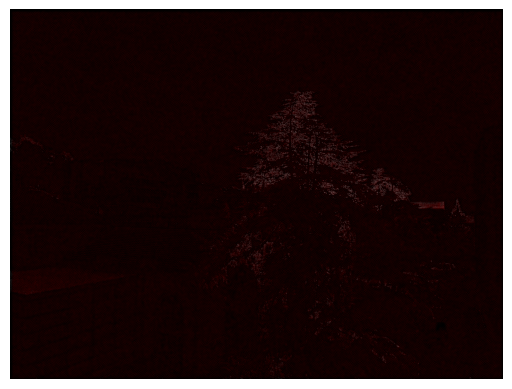

In [1]:
from PIL import Image, ImageOps
import numpy as np
from skimage.color import rgb2gray
from harris import get_harris_corners, anms
import matplotlib.pyplot as plt
from pathlib import Path

def safe_load_image(path=None, apply_exif_orientation=True):
    p = Path(path) if path is not None else None

    if p is not None and p.exists():
        img = Image.open(p).convert("RGB")
        if apply_exif_orientation:
            img = ImageOps.exif_transpose(img)
        arr = np.asarray(img, dtype=np.float32) / 255.0
        gray = rgb2gray(arr)
        return arr, gray

    # fallback: use safe default
    print(f"[warning] Image not found: {path}, using white fallback.")
    h = w = 256
    dummy = np.ones((h, w, 3), dtype=np.float32)
    gray = rgb2gray(dummy)
    return dummy, gray

# img1_path = "wall/w1.jpg"
# img2_path = "wall/w3.jpg"
img1_path = "building2/bt2.jpg"
img2_path = "building2/bt4.jpg"
# img1_path = "building1/bo1.jpg"
# img2_path = "building1/bo3.jpg"

rgb1, gray1 = safe_load_image(path=img1_path)
h1, coords1 = get_harris_corners(gray1, edge_discard=20)
rgb2, gray2 = safe_load_image(path=img2_path)
h2, coords2 = get_harris_corners(gray2, edge_discard=20)

ys, xs = coords1
plt.imshow(h1, cmap='gray')
plt.plot(xs, ys, 'r.', markersize=0.01)
plt.axis('off')
plt.show()


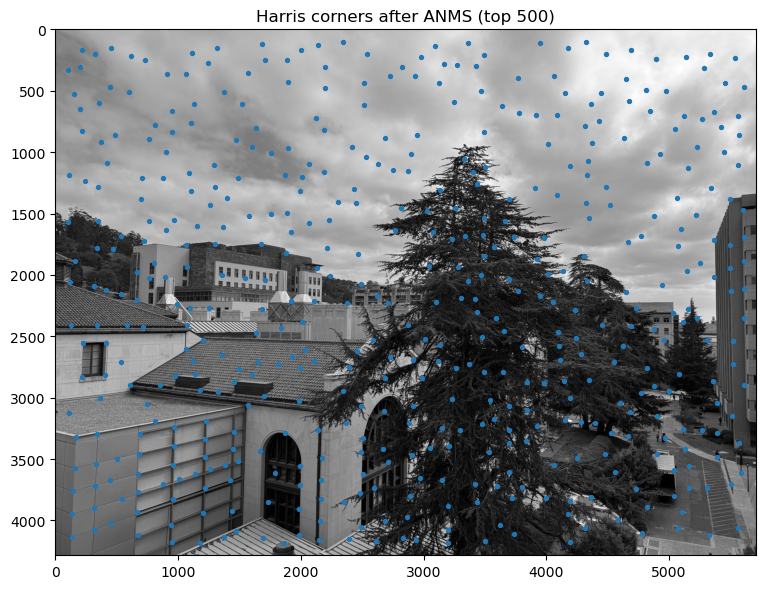

In [2]:

from PIL import ImageFilter

def downsample_grayscale(im_np, max_dim=1200, pre_blur=True, blur_sigma=1.0):
    """
    im_np: 归一化到 [0,1] 的灰度图 (H, W) float
    max_dim: 下采样后图像的最大边长度
    pre_blur: 下采样前是否做高斯模糊（建议 True，抑制混叠）
    blur_sigma: PIL 的 GaussianBlur 的半径（像素）

    返回:
      im_small: 下采样后的灰度图 (float, [0,1])
      scale:    下采样比例 (im_small = im_orig * scale)，例如 0.4
    """
    H, W = im_np.shape[:2]
    orig_max = max(H, W)
    if orig_max <= max_dim:
        return im_np, 1.0

    scale = max_dim / float(orig_max)
    new_w = int(round(W * scale))
    new_h = int(round(H * scale))

    im8 = (im_np * 255.0).clip(0,255).astype(np.uint8)
    pil = Image.fromarray(im8, mode="L")
    if pre_blur and blur_sigma > 0:
        pil = pil.filter(ImageFilter.GaussianBlur(radius=blur_sigma))
    pil_small = pil.resize((new_w, new_h), resample=Image.LANCZOS)
    im_small = np.asarray(pil_small).astype(np.float32) / 255.0
    return im_small, scale

def map_coords_to_original(coords_small, scale):
    """
    将下采样图上的角点坐标映射回原图坐标。
    coords_small: 2 x N (ys, xs)
    scale: 下采样比例（小图 = 原图 * scale）
    """
    ys, xs = coords_small
    ys_full = (ys / scale)
    xs_full = (xs / scale)
    # 你可以选择不四舍五入，保留浮点坐标；可视化/索引时再转 int
    return np.vstack([ys_full, xs_full])

im_small1, scale1 = downsample_grayscale(gray1, max_dim=1200, pre_blur=True, blur_sigma=1.0)
im_small2, scale2 = downsample_grayscale(gray2, max_dim=1200, pre_blur=True, blur_sigma=1.0)

# 3) 在小图上做 Harris + ANMS
edge_discard_orig = 20
edge_discard_small = max(20, int(round(edge_discard_orig * scale1)))  # 边缘剔除也按比例缩放
h_small1, coords_small1 = get_harris_corners(im_small1, edge_discard=edge_discard_small)
coords_keep_small1, radii1 = anms(coords_small1, h_small1, num_keep=500, c_robust=0.9)
h_small2, coords_small2 = get_harris_corners(im_small2, edge_discard=edge_discard_small)
coords_keep_small2, radii2 = anms(coords_small2, h_small2, num_keep=500, c_robust=0.9)

# 4) 映射回原图坐标（若后续要在原图画点/匹配）
coords_keep_full1 = map_coords_to_original(coords_keep_small1, scale1).round().astype(int)
coords_keep_full2 = map_coords_to_original(coords_keep_small2, scale2).round().astype(int)

plt.figure(figsize=(8,6))
plt.imshow(gray1, cmap='gray')
plt.scatter(coords_keep_full1[1], coords_keep_full1[0], s=8)
plt.title("Harris corners after ANMS (top 500)")
plt.tight_layout()
plt.show()

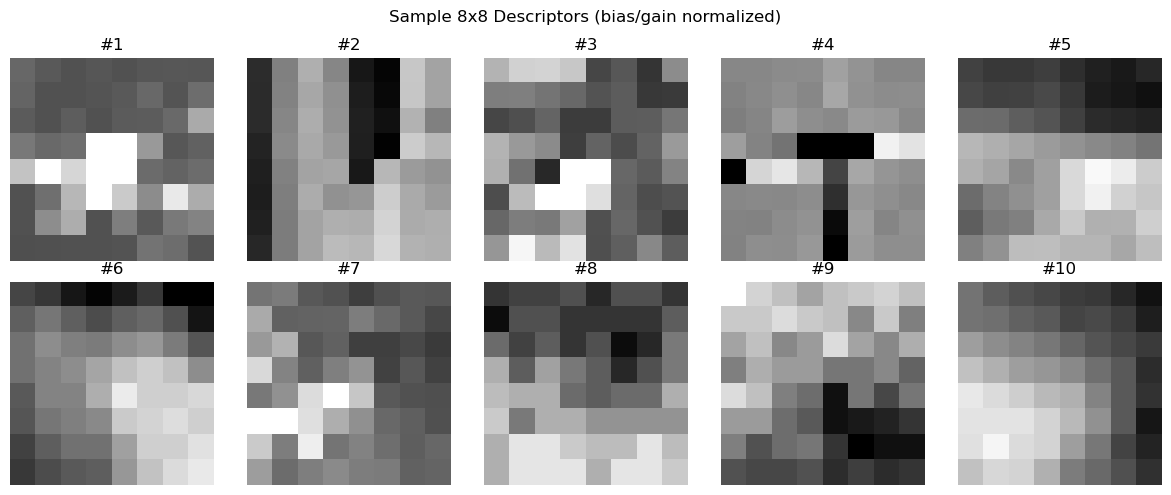

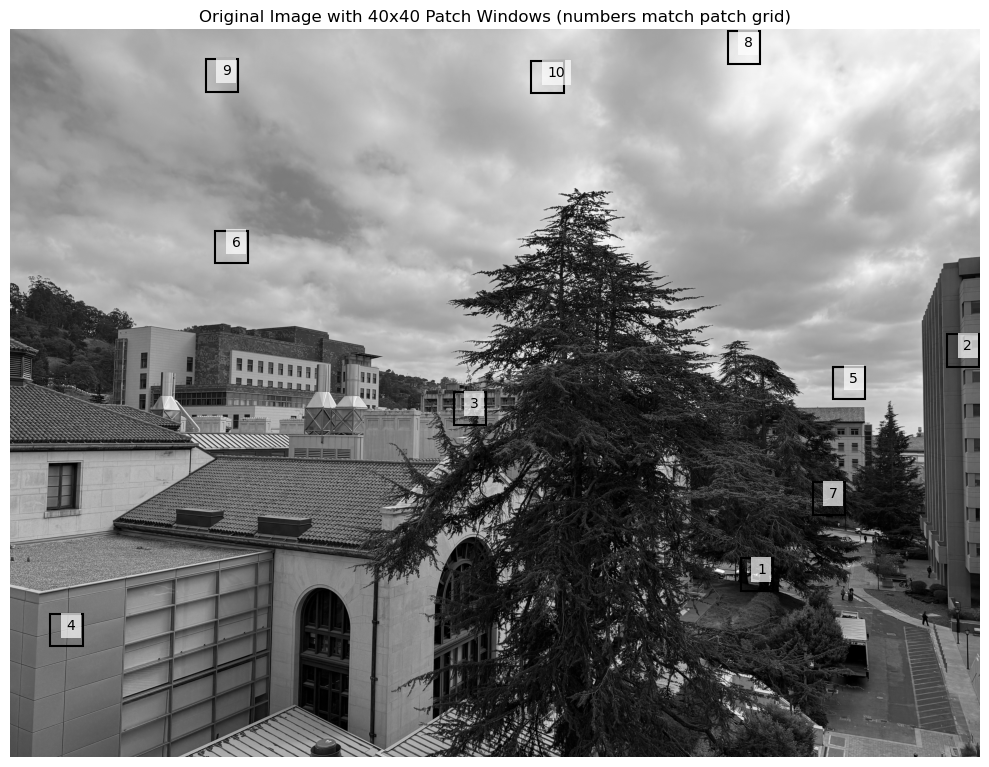

In [3]:
from scipy.ndimage import map_coordinates
import matplotlib.patches as patches

def extract_descriptors(im, coords, patch_size=40, grid_size=8):
    im_h, im_w = im.shape
    half = patch_size // 2
    s = patch_size / grid_size   # 采样步长，40/8=5

    descs = []
    valid_coords = []

    for (y, x) in coords.T:
        # 跳过靠近边缘的点
        if y - half < 0 or y + half >= im_h or x - half < 0 or x + half >= im_w:
            continue

        # 构造 8x8 网格坐标 (浮点坐标)
        ys = np.linspace(y - half + s/2, y + half - s/2, grid_size)
        xs = np.linspace(x - half + s/2, x + half - s/2, grid_size)
        grid_y, grid_x = np.meshgrid(ys, xs, indexing='ij')

        # 双线性插值采样
        patch = map_coordinates(im, [grid_y.ravel(), grid_x.ravel()], order=1, mode='reflect')

        # Bias/Gain normalization
        patch = patch - np.mean(patch)
        std = np.std(patch)
        if std < 1e-5:
            continue
        patch /= std

        descs.append(patch)
        valid_coords.append((y, x))

    if not descs:
        return np.zeros((0, grid_size * grid_size)), np.empty((2, 0))

    descs = np.array(descs)  # (N, 64)
    valid_coords = np.array(valid_coords).T  # (2, N)
    return descs, valid_coords

descs1, valid_coords1 = extract_descriptors(gray1, coords_keep_full1)
descs2, valid_coords2 = extract_descriptors(gray2, coords_keep_full2)

# Choose KSHOW patches to visualize
kshow = 10
idxs = np.linspace(0, descs1.shape[0]-1, kshow, dtype=int)

# ---------------------------
# Visualization 1: grid of 8x8 patches
# ---------------------------
fig, axes = plt.subplots(2, (kshow+1)//2, figsize=(12,5))
axes = axes.ravel()
for i, ax in enumerate(axes):
    if i >= kshow: break
    ax.imshow(descs1[idxs[i]].reshape(8, 8), cmap='gray', vmin=-2, vmax=2)
    ax.set_title(f"#{i+1}")
    ax.axis('off')
plt.suptitle("Sample 8x8 Descriptors (bias/gain normalized)")
plt.tight_layout()
plt.show()

# ---------------------------
# Visualization 2: original image with 40x40 windows marked
# ---------------------------
fig2 = plt.figure(figsize=(10,8))
ax2 = plt.gca()
ax2.imshow(gray1, cmap='gray')
half_full = (40/scale1)/2.0
for i, idx in enumerate(idxs, start=1):
    y, x = valid_coords1[:, idx]
    rect = patches.Rectangle((x-half_full, y-half_full),
                             2*half_full, 2*half_full,
                             fill=False, linewidth=1.5)
    ax2.add_patch(rect)
    ax2.text(x, y-6, f"{i}", fontsize=10,
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
ax2.set_title("Original Image with 40x40 Patch Windows (numbers match patch grid)")
ax2.set_axis_off()
plt.tight_layout()
plt.show()

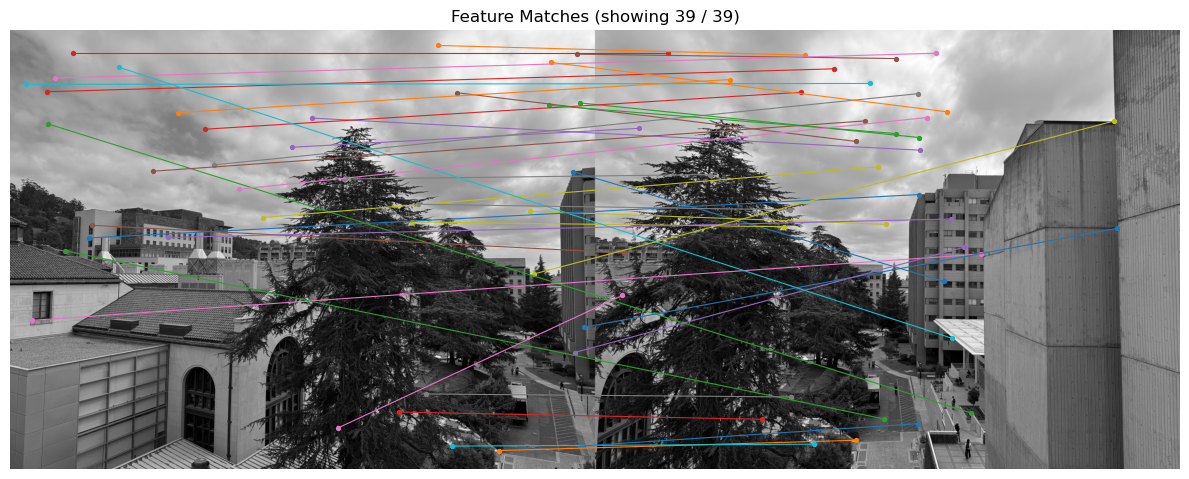

In [4]:
def _pairwise_sq_dists(a, b):
    """
    Compute all pairwise squared Euclidean distances between rows of a and b.
    a: (N, D), b: (M, D)
    returns: (N, M)
    """
    a2 = np.sum(a*a, axis=1, keepdims=True)        # (N,1)
    b2 = np.sum(b*b, axis=1, keepdims=True).T      # (1,M)
    G  = a @ b.T                                   # (N,M)
    d2 = a2 + b2 - 2.0*G
    # numeric safety: distances should be >= 0
    np.maximum(d2, 0, out=d2)
    return d2

def match_descriptors(desc1, desc2, ratio_thresh=0.7, mutual_best=True, eps=1e-12):
    """
    Return matches (i,j) passing Lowe ratio test (1-NN / 2-NN).
    """
    if desc1.size == 0 or desc2.size == 0:
        return np.zeros((0,2), dtype=int), np.zeros((0,), dtype=float)

    # Compute distances image1->image2
    d2 = _pairwise_sq_dists(desc1.astype(np.float32), desc2.astype(np.float32))  # (N1,N2)

    # For each row, find best and second-best matches in image2
    if d2.shape[1] < 2:
        # no 2-NN possible
        return np.zeros((0,2), dtype=int), np.zeros((0,), dtype=float)

    # argpartition to get two smallest per row
    idx2 = np.argpartition(d2, kth=1, axis=1)[:, :2]           # (N1,2) unordered small indices
    # order those two so first is really the best
    i0 = np.take_along_axis(d2, idx2, axis=1)
    order01 = np.argsort(i0, axis=1)
    best2 = np.take_along_axis(idx2, order01, axis=1)          # (N1,2) [best, second]
    d_best  = d2[np.arange(d2.shape[0]), best2[:,0]]
    d_2nd   = d2[np.arange(d2.shape[0]), best2[:,1]]

    # Lowe ratio test
    ratios = d_best / (d_2nd + eps)
    keep = ratios < ratio_thresh
    i_keep = np.where(keep)[0]
    j_keep = best2[keep, 0]

    if mutual_best:
        # Cross-check: j’s best in image1 must be i
        d2_T = d2.T                                        # (N2,N1)
        j_best_i = np.argmin(d2_T[j_keep], axis=1)         # best i for each chosen j
        mutual = (j_best_i == i_keep)
        i_keep = i_keep[mutual]
        j_keep = j_keep[mutual]
        d_best = d_best[keep][mutual]

    matches = np.stack([i_keep, j_keep], axis=1).astype(int)
    return matches, d_best

def draw_matches(img1, pts1, img2, pts2, matches, max_lines=200, s=8):
    """
    Visualize matches by stacking images horizontally and drawing connecting lines.
    pts1, pts2 are (2, N) in (y,x) order.
    """
    if matches.shape[0] == 0:
        print("No matches to draw.")
        return

    # Convert to RGB for plotting
    if img1.ndim == 2: img1_vis = np.stack([img1]*3, axis=-1)
    else: img1_vis = img1
    if img2.ndim == 2: img2_vis = np.stack([img2]*3, axis=-1)
    else: img2_vis = img2

    H1, W1 = img1_vis.shape[:2]
    H2, W2 = img2_vis.shape[:2]
    H = max(H1, H2)

    canvas = np.ones((H, W1+W2, 3), dtype=img1_vis.dtype)
    canvas[:H1, :W1] = img1_vis
    canvas[:H2, W1:W1+W2] = img2_vis

    plt.figure(figsize=(12, 8))
    plt.imshow(canvas, cmap='gray')
    M = min(max_lines, matches.shape[0])

    y1, x1 = pts1
    y2, x2 = pts2
    for k in range(M):
        i, j = matches[k]
        x1k, y1k = x1[i], y1[i]
        x2k, y2k = x2[j] + W1, y2[j]  # shift by W1 on x-axis
        # points
        plt.scatter([x1k, x2k], [y1k, y2k], s=s)
        # line
        plt.plot([x1k, x2k], [y1k, y2k], linewidth=0.8)
    plt.axis('off')
    plt.title(f"Feature Matches (showing {M} / {matches.shape[0]})")
    plt.tight_layout()
    plt.show()

# ============================
# Example usage
# (Assuming you already have descs1, descs2, coords1_full, coords2_full, and images gray1, gray2)
# ============================
matches, dists = match_descriptors(descs1, descs2, ratio_thresh=0.7, mutual_best=True)
draw_matches(gray1, valid_coords1, gray2, valid_coords2, matches, max_lines=150)

In [5]:
def _to_h(pts):
    """(2,N) -> (3,N) homogeneous."""
    return np.vstack([pts, np.ones((1, pts.shape[1]))])

def _from_h(ph):
    """(3,N) -> (2,N) inhomogeneous."""
    w = ph[2:3, :]
    return ph[:2, :] / (w + 1e-12)

def project_points_h(H, pts):
    """
    Apply homography H to 2D points.
    pts: (2,N) in (y,x), treated as (x,y) in geometry -> be careful.
    We'll convert to (x,y) for math and convert back to (y,x) on return.
    """
    # swap to (x,y)
    xy = np.vstack([pts[1], pts[0]])  # (2,N)
    xy_h = np.vstack([xy, np.ones((1, xy.shape[1]))])
    proj = H @ xy_h
    proj = proj / (proj[2:3] + 1e-12)
    xy2 = proj[:2]
    # back to (y,x)
    yx = np.vstack([xy2[1], xy2[0]])
    return yx

def _normalize_points(pts):
    """
    Hartley normalization for numeric stability.
    pts: (2,N) in (y,x). We convert to (x,y) for transform.
    Returns: T (3x3), ptsn (2,N) normalized (y,x)
    """
    xy = np.vstack([pts[1], pts[0]])  # (2,N) as (x,y)
    mean = np.mean(xy, axis=1, keepdims=True)
    d = xy - mean
    mean_abs_dev = np.mean(np.sqrt(np.sum(d**2, axis=0)))
    s = np.sqrt(2) / (mean_abs_dev + 1e-12)
    # Transform in (x,y): scale and translate
    T_xy = np.array([[s, 0, -s*mean[0,0]],
                     [0, s, -s*mean[1,0]],
                     [0, 0, 1]], dtype=float)
    # Apply
    xy_h = np.vstack([xy, np.ones((1, xy.shape[1]))])
    xy_n = T_xy @ xy_h
    xy_n = xy_n[:2]
    # back to (y,x)
    yx_n = np.vstack([xy_n[1], xy_n[0]])
    return T_xy, yx_n

# ---------- DLT with normalization ----------
def dlt_homography_normalized(pts1, pts2):
    """
    Compute H mapping pts2 -> pts1 using normalized DLT.
    pts1, pts2: (2,N) (y,x). Need N>=4 and not all collinear.
    """
    assert pts1.shape[1] >= 4 and pts2.shape[1] >= 4
    # Normalize both sets
    T2, pts2n = _normalize_points(pts2)
    T1, pts1n = _normalize_points(pts1)
    # Build A (2N x 9). Work in (x,y) order for algebra
    x1, y1 = pts1n[1], pts1n[0]
    x2, y2 = pts2n[1], pts2n[0]
    N = pts1n.shape[1]
    A = np.zeros((2*N, 9), dtype=float)
    # Row pairs
    # [ -x2, -y2, -1,  0,  0,  0,  x1*x2, x1*y2, x1 ]
    # [  0,  0,  0, -x2, -y2, -1,  y1*x2, y1*y2, y1 ]
    A[0::2, 0] = -x2
    A[0::2, 1] = -y2
    A[0::2, 2] = -1
    A[0::2, 6] = x1 * x2
    A[0::2, 7] = x1 * y2
    A[0::2, 8] = x1

    A[1::2, 3] = -x2
    A[1::2, 4] = -y2
    A[1::2, 5] = -1
    A[1::2, 6] = y1 * x2
    A[1::2, 7] = y1 * y2
    A[1::2, 8] = y1

    # Solve Ah = 0 via SVD
    _, _, Vt = np.linalg.svd(A, full_matrices=False)
    h = Vt[-1, :]
    Hn = h.reshape(3,3)

    # Denormalize: H = T1^{-1} * Hn * T2
    T1_inv = np.linalg.inv(T1)
    H = T1_inv @ Hn @ T2
    # Scale so H[2,2]=1
    if abs(H[2,2]) > 1e-12:
        H /= H[2,2]
    return H

# ---------- RANSAC ----------
def ransac_homography(pts1, pts2, num_iters=2000, thresh=4.0, refine=True, seed=None):
    """
    Robustly estimate H (pts2 -> pts1) with 4-point RANSAC.
    pts1, pts2: (2,N) float arrays (y,x).
    thresh: inlier threshold in pixels (reprojection error).
    """
    assert pts1.shape[1] == pts2.shape[1]
    N = pts1.shape[1]
    if N < 4:
        raise ValueError("Need at least 4 matches for homography.")

    rng = np.random.default_rng(seed)
    best_inliers = None
    best_err = np.inf
    H_best = None

    # Prebuild indices
    all_idx = np.arange(N)

    for it in range(num_iters):
        # 1) Sample 4 correspondences
        idx = rng.choice(all_idx, size=4, replace=False)
        H = dlt_homography_normalized(pts1[:, idx], pts2[:, idx])

        # 2) Compute reprojection error (forward error pts2->pts1)
        proj = project_points_h(H, pts2)          # (2,N) in (y,x)
        err = np.sqrt(np.sum((proj - pts1)**2, axis=0))  # (N,)

        # 3) Inliers
        inliers = err < thresh
        n_in = np.count_nonzero(inliers)
        if n_in == 0:
            continue

        # Mean error among inliers
        mean_err = err[inliers].mean()

        # 4) Keep the best by: more inliers, tie-break by lower mean error
        if (best_inliers is None) or (n_in > np.count_nonzero(best_inliers)) or \
           (n_in == np.count_nonzero(best_inliers) and mean_err < best_err):
            best_inliers = inliers
            best_err = mean_err
            H_best = H

    if H_best is None:
        raise RuntimeError("RANSAC failed to find a valid homography.")

    # Optional refinement with all inliers
    if refine:
        idx_in = np.where(best_inliers)[0]
        H_best = dlt_homography_normalized(pts1[:, idx_in], pts2[:, idx_in])
        proj = project_points_h(H_best, pts2[:, idx_in])
        best_err = np.sqrt(np.sum((proj - pts1[:, idx_in])**2, axis=0)).mean()

    return H_best, best_inliers, best_err

# ---------- (Optional) simple stitching using skimage ----------
def stitch_two(img1, img2, H_2to1, pad=400, mode="average"):
    """
    Warp img2 into img1 coords using H_2to1, return mosaic.
    Requires: skimage.transform
    mode: 'left' (prefer img1), 'right' (prefer img2), 'average' (blend)
    """
    try:
        from skimage.transform import warp, ProjectiveTransform
    except Exception as e:
        raise ImportError("Requires scikit-image for warping. Install scikit-image.") from e

    # convert to float [0,1]
    def _to_float(im):
        im = im.astype(np.float32)
        if im.max() > 1.0: im = im / 255.0
        return im

    I1 = _to_float(img1)
    I2 = _to_float(img2)

    H, W = I1.shape[:2]
    out_H = H + pad*2
    out_W = W + pad*2

    # Canvas transform to center img1 with padding
    T_pad = np.array([[1, 0, pad],
                      [0, 1, pad],
                      [0, 0, 1]], dtype=float)

    # Warp img1 by identity (just place it)
    canvas = np.zeros((out_H, out_W, I1.shape[2] if I1.ndim==3 else 1), dtype=np.float32)
    mask1 = np.zeros((out_H, out_W), dtype=np.float32)

    # paste img1
    y0, y1, x0, x1 = pad, pad+H, pad, pad+W
    if I1.ndim == 2:
        canvas[y0:y1, x0:x1, 0] = I1
    else:
        canvas[y0:y1, x0:x1, :] = I1
    mask1[y0:y1, x0:x1] = 1.0

    # Warp img2 using H_2to1 with padding
    H_warp = T_pad @ H_2to1
    tf = ProjectiveTransform(H_warp)
    warped2 = warp(I2, tf.inverse, output_shape=(out_H, out_W), order=1)
    mask2 = (warp(np.ones_like(I2[...,0]), tf.inverse, output_shape=(out_H, out_W), order=0) > 0).astype(np.float32)

    # Blending
    if I1.ndim == 2:
        warped2 = warped2[..., 0:1]
    if mode == "left":
        out = np.where(mask2[...,None] > 0, warped2, canvas)
    elif mode == "right":
        out = np.where(mask1[...,None] > 0, canvas, warped2)
    else:  # average
        w1 = mask1[...,None]; w2 = mask2[...,None]
        denom = (w1 + w2); denom[denom == 0] = 1.0
        out = (canvas*w1 + warped2*w2) / denom

    # squeeze if grayscale
    if out.shape[2] == 1:
        out = out[...,0]
    return out


# Build matched lists
i1 = matches[:,0]
i2 = matches[:,1]
pts1_m = valid_coords1[:, i1].astype(np.float64)
pts2_m = valid_coords2[:, i2].astype(np.float64)

# RANSAC
H_2to1, inliers, mean_err = ransac_homography(pts1_m, pts2_m, num_iters=2000, thresh=4.0, refine=True, seed=0)
print("Inliers:", np.count_nonzero(inliers), " / ", pts1_m.shape[1], "  mean err:", mean_err)

# Visualize inliers only (optional)
import matplotlib.pyplot as plt
from copy import deepcopy
from math import ceil
def draw_inlier_matches(img1, pts1, img2, pts2, inlier_mask, max_lines=200):
    good = np.where(inlier_mask)[0]
    m = np.stack([good, good], axis=1)  # already aligned lists
    # reuse your draw_matches from B.3 if you have it:
    draw_matches(img1, pts1[:, good], img2, pts2[:, good], np.arange(len(good))[:,None].repeat(2,1), max_lines=max_lines)

# Mosaic (optional, needs skimage)
mosaic = stitch_two(rgb1, rgb2, H_2to1, pad=400, mode="average")
plt.figure(figsize=(12,8))
plt.imshow(mosaic, cmap='gray' if mosaic.ndim==2 else None)
plt.axis('off')
plt.show()

AssertionError: 